# 2. Mid-Scale Dense Random Walk Decoder-Only Autoregressive Graph Shortest Path Transformer
## Causal Language Modeling Mechanics over Dense Multi-Dimensional Traversal Traces

### Executive Summary & Educational Motivation
Extracting direct shortest paths from complex, noisy algorithmic execution traces is a central benchmark in neural algorithmic reasoning. While standard Encoder-Decoder architectures utilize cross-attention layers to bridge trace encodings and path decoding, **Decoder-Only Causal Transformers** unify the trace prompt and target path into a single sequence, mirroring modern Large Language Model (LLM) paradigms (e.g., GPT-4, LLaMA, DeepSeek).

In this notebook, we solve the **Dense Random Walk (`rw_dense`)** graph shortest path extraction task using a Decoder-Only Autoregressive Graph Transformer. The dense random walk dataset represents a significant step up in topological difficulty compared to sparse DFS or standard random walks:
- **4+ Minimum Node Connectivity Guarantee**: Every node in the graph strictly maintains degree $k \ge 4$ ($d_{\text{avg}} \ge 5.0$), requiring the causal attention mechanism to navigate minimum 4-way decision bifurcations at every step.
- **Multi-Layered Lattices & High Clustering**: Graphs are structured as 2D/3D multi-layered meshes ($N=30$) with high clustering coefficients ($\text{CC} \ge 0.45$) and decoy edge ratios ($> 60\%$).
- **Unified Causal Sequence Formulation**: Execution trace prompt $T = [t_1, \dots, t_K]$ ($30 \le K \le 50$) and target path $P^* = [p_1^*, \dots, p_M^*]$ ($10 \le M \le 20$) are concatenated into a single input sequence:
$$X = [t_1, t_2, \dots, t_K, p_1^*, p_2^*, \dots, p_M^*, \text{STOP_TOKEN}]$$

The model supports dynamic configuration across three model sizes (`small`, `base`, `large`), selective loss masking over trace prompt tokens, and dynamic checkpoint serialization.

---

### Mathematical Problem Formulation

#### 1. Unified Sequence Representation
Given a goal-terminated Dense Random Walk trace $T = [t_1, t_2, \dots, t_K]$ ($30 \le K \le 50$) where $t_1 = s$ and $t_K = g$, and ground-truth shortest path $P^* = [p_1^*, p_2^*, \dots, p_M^*]$ ($10 \le M \le 20$), the sequence is concatenated into:
$$X = [t_1, t_2, \dots, t_K, p_1^*, p_2^*, \dots, p_M^*, \text{STOP_TOKEN}]$$
padded to length $L_{\text{max}} = 71$ (`MAX_SRC_LEN = 50` + `MAX_TGT_LEN = 21`).

#### 2. Causal Masking & Next-Token Prediction
For input sequence $X_{\text{in}} = X[:-1]$, embeddings and sinusoidal positional encodings are computed:
$$H_0 = \text{Embedding}(X_{\text{in}}) + \text{PositionalEncoding}(X_{\text{in}}) \in \mathbb{R}^{L \times d_{\text{model}}}$$

The decoder applies $N$ layers of Causal Self-Attention using lower-triangular causal mask $M_{\text{causal}}$:
$$M_{\text{causal}}[i, j] = \begin{cases} 0 & \text{if } i \ge j \\ -\infty & \text{if } i < j \end{cases}$$
$$H_l = \text{CausalTransformerBlock}(H_{l-1}, M_{\text{causal}})$$
$$Z = \text{Linear}(H_N) \in \mathbb{R}^{L \times V}$$

#### 3. Selective Loss Masking
Cross-entropy loss is evaluated against target labels $Y = X[1:]$. To focus optimization exclusively on shortest path extraction, loss is masked out for trace prompt positions ($i < K-1$):
$$\mathcal{L} = -\frac{1}{\sum m_i} \sum_{i=K-1}^{L-1} \log P(Y_i \mid X_{\le i})$$
where $m_i = 1$ for target path tokens and $0$ for trace prompt and padding tokens.

#### 4. Autoregressive Rollout & Multi-Size Capacity
During inference (`solve_graph_autoregressive`), the model is prompted with trace $T = [t_1, \dots, t_K]$ and greedily samples path tokens $p_m$ until `STOP_TOKEN`. Model capacity is configurable across `small` ($d_{\text{model}}=32$), `base` ($d_{\text{model}}=64$), and `large` ($d_{\text{model}}=128$).


In [1]:
# Cell 1: Environment Setup, Seeds, and Google Drive Configuration

import os
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Ensure directories exist relative to CWD
if os.path.basename(os.getcwd()) == "graphs":
    os.makedirs("../charts", exist_ok=True)
    os.makedirs("charts", exist_ok=True)
    os.makedirs("checkpoints", exist_ok=True)
    LOCAL_DATA_PATH = "data/graph_rw_dense_dataset.pt"
    LOCAL_CKPT_DIR = "checkpoints"
else:
    os.makedirs("charts", exist_ok=True)
    os.makedirs("graphs/charts", exist_ok=True)
    os.makedirs("graphs/checkpoints", exist_ok=True)
    LOCAL_DATA_PATH = "src/static/data/graph_rw_dense_dataset.pt"
    LOCAL_CKPT_DIR = "graphs/checkpoints"

torch.set_num_threads(1)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Google Drive Mount & Path Resolution
def setup_drive_paths():
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        data_path = "/content/drive/MyDrive/graph_data/graph_rw_dense_10x_dataset.pt"
        ckpt_dir = "/content/drive/MyDrive/graph_checkpoints"
    except ImportError:
        data_path = LOCAL_DATA_PATH
        ckpt_dir = LOCAL_CKPT_DIR

    os.makedirs(ckpt_dir, exist_ok=True)
    print(f"Dataset path: {data_path}")
    print(f"Checkpoints path: {ckpt_dir}")
    return data_path, ckpt_dir

DATASET_PATH, CKPT_DIR = setup_drive_paths()


Mounted at /content/drive
Dataset path: /content/drive/MyDrive/graph_data/graph_rw_dense_10x_dataset.pt
Checkpoints path: /content/drive/MyDrive/graph_checkpoints


### Dense Random Walk Dataset Loading & PyTorch Dataset Class
Loads the pre-generated Dense Random Walk dataset (`graph_rw_dense_dataset.pt`, $d_{\text{min}} \ge 4$, $d_{\text{avg}} \ge 5.0$).
- `trace`: Input 1D dense random walk trace of length $K$ ($30 \le K \le 50$).
- `sp`: Ground-truth shortest path of length $M$ ($10 \le M \le 20$).
- Concatenates sequence into `[trace + sp + STOP_TOKEN]` padded to `MAX_COMBINED_LEN = 71` (`MAX_SRC_LEN=50` + `MAX_TGT_LEN=21`).
- Masks target label loss for input trace prompt positions ($i < K-1$), ensuring 100% of gradient updates target path tokens.


In [2]:
# Cell 2: Import Dense Random Walk Dataset & Define PyTorch Causal Dataset

search_paths = [
    DATASET_PATH,
    "data/graph_rw_dense_dataset.pt",
    "graphs/data/graph_rw_dense_dataset.pt",
    "src/static/data/graph_rw_dense_dataset.pt"
]

actual_dataset_path = None
for path in search_paths:
    if os.path.exists(path):
        actual_dataset_path = path
        break

if actual_dataset_path is None:
    raise FileNotFoundError(f"Dataset file not found in search paths: {search_paths}.")

dataset_payload = torch.load(actual_dataset_path, weights_only=False)
train_raw = dataset_payload['train']
val_raw = dataset_payload['val']
test_raw = dataset_payload['test']

VOCAB_SIZE = dataset_payload.get('vocab_size', 42)
PAD_TOKEN = dataset_payload.get('pad_token', 40)
STOP_TOKEN = dataset_payload.get('stop_token', 41)
MAX_SRC_LEN = dataset_payload.get('max_src_len', 50)
MAX_TGT_LEN = dataset_payload.get('max_tgt_len', 21)
MAX_COMBINED_LEN = MAX_SRC_LEN + MAX_TGT_LEN

class GraphRWDenseDecoderOnlyDataset(Dataset):
    def __init__(self, raw_data, max_combined_len=MAX_COMBINED_LEN):
        self.samples = []
        self.raw_data = raw_data
        for item in raw_data:
            trace, sp, G, mapping = item[0], item[1], item[2], item[3]
            backtracks = item[4] if len(item) > 4 else 0
            node_backtraces = item[5] if len(item) > 5 else {}

            K = len(trace)
            tgt_seq = list(sp) + [STOP_TOKEN]
            full_seq = list(trace) + tgt_seq
            pad_len = max_combined_len - len(full_seq)
            full_seq_padded = full_seq + [PAD_TOKEN] * pad_len

            # Causal Sequence: Input = X[:-1], Target = X[1:]
            inp = full_seq_padded[:-1]
            lbl = list(full_seq_padded[1:])

            # Mask out loss on input trace prompt tokens (positions 0 to K-2)
            for idx in range(K - 1):
                lbl[idx] = PAD_TOKEN

            inp_mask = [t == PAD_TOKEN for t in inp]

            self.samples.append((
                torch.tensor(inp, dtype=torch.long),
                torch.tensor(lbl, dtype=torch.long),
                torch.tensor(inp_mask, dtype=torch.bool),
                trace,
                sp,
                G,
                backtracks,
                node_backtraces
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

def graph_decoder_only_collate_fn(batch):
    inp = torch.stack([item[0] for item in batch])
    lbl = torch.stack([item[1] for item in batch])
    inp_mask = torch.stack([item[2] for item in batch])
    traces = [item[3] for item in batch]
    sps = [item[4] for item in batch]
    graphs = [item[5] for item in batch]
    backtracks = [item[6] for item in batch]
    node_backtraces = [item[7] for item in batch]
    return inp, lbl, inp_mask, traces, sps, graphs, backtracks, node_backtraces

train_dataset = GraphRWDenseDecoderOnlyDataset(train_raw)
val_dataset = GraphRWDenseDecoderOnlyDataset(val_raw)
test_dataset = GraphRWDenseDecoderOnlyDataset(test_raw)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=graph_decoder_only_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=graph_decoder_only_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=graph_decoder_only_collate_fn)

print(f"Dense RW Decoder-Only Datasets loaded: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")


Dense RW Decoder-Only Datasets loaded: Train=30000, Val=500, Test=500


### Multi-Size Decoder-Only Graph Shortest Path Transformer Architecture
Supports dynamic network capacity scaling via `MODEL_SIZES` configuration dictionary:
- **`small`**: `embed_dim = 32`, `num_heads = 2`, `hidden_dim = 64`, `num_layers = 1` (~25k params).
- **`base`**: `embed_dim = 64`, `num_heads = 4`, `hidden_dim = 128`, `num_layers = 2` (~150k params).
- **`large`**: `embed_dim = 128`, `num_heads = 8`, `hidden_dim = 256`, `num_layers = 4` (~850k params).

Key architectural mechanisms:
1. **Token Embedding & Sinusoidal Positional Encoding**.
2. **Causal Transformer Stack**: Transformer Encoder layers with boolean lower-triangular causal self-attention mask.
3. **Linear Output Projection**: Maps hidden representations $h_i \in \mathbb{R}^{d_{\text{model}}}$ to vocabulary logits $\in \mathbb{R}^{42}$.
4. **Unguided Autoregressive Rollout (`solve_graph_autoregressive`)**: Prompts model with 1D trace $T = [t_1, \dots, t_K]$ and iteratively samples next path tokens.


In [3]:
# Cell 3: Model Architecture Definition & Sizing Configurations

MODEL_SIZES = {
    'small': {'embed_dim': 32, 'num_heads': 2, 'hidden_dim': 64, 'num_layers': 1},
    'base': {'embed_dim': 64, 'num_heads': 4, 'hidden_dim': 128, 'num_layers': 2},
    'large': {'embed_dim': 128, 'num_heads': 8, 'hidden_dim': 256, 'num_layers': 4}
}

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=150):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class DecoderOnlyGraphTransformer(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=64, num_heads=4, hidden_dim=128, num_layers=2):
        super(DecoderOnlyGraphTransformer, self).__init__()
        self.embed_dim = embed_dim
        self.token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_TOKEN)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len=150)

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(embed_dim, vocab_size)

    def generate_square_subsequent_mask(self, sz, device):
        mask = torch.triu(torch.ones(sz, sz, device=device, dtype=torch.bool), diagonal=1)
        return mask

    def forward(self, x, padding_mask=None, causal_mask=None):
        x_emb = self.pos_encoder(self.token_embedding(x))
        out = self.transformer(x_emb, mask=causal_mask, src_key_padding_mask=padding_mask)
        logits = self.fc_out(out)
        return logits

    def solve_graph_autoregressive(self, traces, max_tgt_len=MAX_TGT_LEN, device='cpu'):
        self.eval()
        batch_size = len(traces)

        # Prompt with input trace tokens
        curr_seqs = [list(tr) for tr in traces]
        generated_paths = [[] for _ in range(batch_size)]
        finished = [False] * batch_size

        for step in range(max_tgt_len - 1):
            if all(finished):
                break

            curr_max_len = max(len(s) for s in curr_seqs)
            inp = torch.full((batch_size, curr_max_len), PAD_TOKEN, dtype=torch.long, device=device)
            inp_mask = torch.zeros((batch_size, curr_max_len), dtype=torch.bool, device=device)

            for b in range(batch_size):
                s = curr_seqs[b]
                inp[b, :len(s)] = torch.tensor(s, dtype=torch.long, device=device)
                inp_mask[b, len(s):] = True

            causal_mask = self.generate_square_subsequent_mask(curr_max_len, device)
            logits = self.forward(inp, padding_mask=inp_mask, causal_mask=causal_mask)

            for b in range(batch_size):
                if finished[b]:
                    continue
                last_idx = len(curr_seqs[b]) - 1
                next_tok = torch.argmax(logits[b, last_idx, :]).item()
                if next_tok in (STOP_TOKEN, PAD_TOKEN):
                    finished[b] = True
                else:
                    curr_seqs[b].append(next_tok)
                    generated_paths[b].append(next_tok)

        return generated_paths

selected_size = 'base'  # Default size: 'small', 'base', or 'large'
size_params = MODEL_SIZES[selected_size]
model = DecoderOnlyGraphTransformer(
    vocab_size=VOCAB_SIZE,
    embed_dim=size_params['embed_dim'],
    num_heads=size_params['num_heads'],
    hidden_dim=size_params['hidden_dim'],
    num_layers=size_params['num_layers']
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"DecoderOnlyGraphTransformer (Size: {selected_size.upper()}) initialized. Total Parameters: {total_params:,}")


DecoderOnlyGraphTransformer (Size: BASE) initialized. Total Parameters: 72,362


### Multi-Metric Evaluation Helper Functions
Evaluates the model across four core metrics:
1. **Teacher-Forcing Cross-Entropy Loss**: Standard training loss on target path tokens.
2. **Teacher-Forcing Token Accuracy (%)**: Per-token accuracy under teacher forcing.
3. **Autoregressive Rollout Exact Path Match (%)**: Percentage of ground-truth paths perfectly reconstructed without a single token error.
4. **Path Connectivity Validity (%)**: Percentage of predicted paths that form valid edge connections on $G$ terminating at goal $g$.


In [4]:
# Cell 4: Multi-Metric Evaluation Helper Functions

criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

def evaluate_model(model, dataloader, device, run_rollout=True):
    model.eval()
    total_loss = 0.0
    total_tf_tokens = 0
    correct_tf_tokens = 0

    exact_matches = 0
    total_sequences = 0
    valid_paths = 0

    with torch.no_grad():
        for inp, lbl, inp_mask, traces, sps, graphs, backtracks, node_backtraces in dataloader:
            inp, lbl = inp.to(device), lbl.to(device)
            inp_mask = inp_mask.to(device)

            sz = inp.size(1)
            causal_mask = model.generate_square_subsequent_mask(sz, device)

            logits = model(inp, padding_mask=inp_mask, causal_mask=causal_mask)

            loss = criterion(logits.reshape(-1, VOCAB_SIZE), lbl.reshape(-1))
            total_loss += loss.item() * inp.size(0)

            preds_tf = torch.argmax(logits, dim=-1)
            valid_tokens = (lbl != PAD_TOKEN)
            correct_tf_tokens += ((preds_tf == lbl) & valid_tokens).sum().item()
            total_tf_tokens += valid_tokens.sum().item()

            if run_rollout:
                pred_seqs = model.solve_graph_autoregressive(traces, device=device)

                for i in range(len(traces)):
                    total_sequences += 1
                    clean_pred = pred_seqs[i]
                    clean_tgt = list(sps[i])

                    if clean_pred == clean_tgt:
                        exact_matches += 1

                    G_eval = graphs[i]
                    if len(clean_pred) >= 2 and clean_pred[0] == clean_tgt[0] and clean_pred[-1] == clean_tgt[-1]:
                        is_valid = True
                        for k in range(len(clean_pred) - 1):
                            u, v = clean_pred[k], clean_pred[k+1]
                            if not G_eval.has_edge(u, v):
                                is_valid = False
                                break
                        if is_valid:
                            valid_paths += 1

    mean_loss = total_loss / len(dataloader.dataset)
    tf_acc = (correct_tf_tokens / max(1, total_tf_tokens)) * 100.0
    exact_match_acc = (exact_matches / max(1, total_sequences)) * 100.0 if run_rollout else 0.0
    path_validity_acc = (valid_paths / max(1, total_sequences)) * 100.0 if run_rollout else 0.0

    return mean_loss, tf_acc, exact_match_acc, path_validity_acc

print("Multi-metric evaluation helpers initialized.")


Multi-metric evaluation helpers initialized.


### Configurable Training Loop with Dynamic Checkpointing & Size Sizing
The `config` dictionary provides full training and architectural control:
- `model_size`: Chooses network capacity (`'small'`, `'base'`, or `'large'`).
- `restart_training`: When `True`, bypasses previous checkpoints and starts fresh from epoch 1.
- `run_full_training`: When `True`, trains for the full `total_epochs` (e.g., 20 epochs).
- `resume_training`: Resumes from the latest size-specific checkpoint (`decoder_only_ar_graph_transformer_rw_dense_{model_size}_latest.pt`).
- Validation executes **strictly every 10 epochs**.


In [5]:
# Cell 5: Configurable Training Loop with Sizing Controls

config = {
    "model_size": "base",        # Options: 'small', 'base', 'large'
    "restart_training": True,   # Set to True to skip existing checkpoints and start fresh
    "run_full_training": True,  # Set to True to train for total_epochs ignoring epochs_to_train
    "resume_training": True,    # Resumes from latest size checkpoint if restart_training is False
    "total_epochs": 1000,
    "save_every": 100,
    "validate_every": 25,
    "epochs_to_train": 20,      # Interactive execution chunk size
    "learning_rate": 1e-3,
    "batch_size": 64
}

# Instantiate model based on config['model_size']
size_params = MODEL_SIZES.get(config["model_size"], MODEL_SIZES['base'])
model = DecoderOnlyGraphTransformer(
    vocab_size=VOCAB_SIZE,
    embed_dim=size_params['embed_dim'],
    num_heads=size_params['num_heads'],
    hidden_dim=size_params['hidden_dim'],
    num_layers=size_params['num_layers']
).to(device)

ckpt_prefix = f"decoder_only_ar_graph_transformer_rw_dense_{config['model_size']}"
latest_ckpt_path = os.path.join(CKPT_DIR, f"{ckpt_prefix}_latest.pt")
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=1e-4)

start_epoch = 1
history = {
    'train_loss': [],
    'val_epochs': [],
    'val_loss': [],
    'val_tf_acc': [],
    'val_exact_match': [],
    'val_path_validity': []
}

if config.get("restart_training", False):
    print(f"Config 'restart_training' is True: Fresh initialization for size {config['model_size'].upper()}.")
    start_epoch = 1
elif config.get("resume_training", True) and os.path.exists(latest_ckpt_path):
    try:
        print(f"Loading checkpoint from '{latest_ckpt_path}'...")
        checkpoint = torch.load(latest_ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        if 'history' in checkpoint:
            history = checkpoint['history']
        print(f"Resumed training from epoch {start_epoch}.")
    except Exception as e:
        print(f"Checkpoint incompatible ({e}). Starting fresh training from epoch 1...")
        start_epoch = 1
else:
    print("Starting training from scratch...")

if config.get("run_full_training", False):
    end_epoch = config["total_epochs"]
    print(f"Config 'run_full_training' is True: Running full training up to {end_epoch} epochs.")
else:
    end_epoch = min(start_epoch + config["epochs_to_train"] - 1, config["total_epochs"])
    print(f"Running training chunk: epochs {start_epoch} to {end_epoch} (Config Total Target: {config['total_epochs']} epochs)...")

start_train_time = time.time()

for epoch in range(start_epoch, end_epoch + 1):
    model.train()
    running_loss = 0.0

    for inp, lbl, inp_mask, _, _, _, _, _ in train_loader:
        inp, lbl = inp.to(device), lbl.to(device)
        inp_mask = inp_mask.to(device)

        sz = inp.size(1)
        causal_mask = model.generate_square_subsequent_mask(sz, device)

        optimizer.zero_grad()
        logits = model(inp, padding_mask=inp_mask, causal_mask=causal_mask)

        loss = criterion(logits.reshape(-1, VOCAB_SIZE), lbl.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * inp.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    history['train_loss'].append(train_loss)

    if epoch % config["validate_every"] == 0 or epoch == end_epoch:
        val_loss, val_tf_acc, val_exact_match, val_path_validity = evaluate_model(
            model, val_loader, device, run_rollout=True
        )
        history['val_epochs'].append(epoch)
        history['val_loss'].append(val_loss)
        history['val_tf_acc'].append(val_tf_acc)
        history['val_exact_match'].append(val_exact_match)
        history['val_path_validity'].append(val_path_validity)

        print(f"Epoch {epoch:04d}/{config['total_epochs']:04d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val TF Acc: {val_tf_acc:.2f}% | Rollout Exact Match: {val_exact_match:.2f}% | "
              f"Path Validity: {val_path_validity:.2f}%")
    elif epoch < config["validate_every"]:
        if epoch % 5 == 0 or epoch == start_epoch:
            print(f"Epoch {epoch:04d}/{config['total_epochs']:04d} | Train Loss: {train_loss:.4f} | (Validation skipped)")

    if epoch % config["save_every"] == 0 or epoch == end_epoch:
        checkpoint_payload = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': config,
            'history': history
        }
        torch.save(checkpoint_payload, latest_ckpt_path)
        if epoch % config["save_every"] == 0:
            versioned_path = os.path.join(CKPT_DIR, f"{ckpt_prefix}_epoch_{epoch}.pt")
            torch.save(checkpoint_payload, versioned_path)
            print(f"Saved versioned checkpoint: '{versioned_path}'")

total_train_time = time.time() - start_train_time
print(f"\nDense RW Decoder-Only Training complete in {total_train_time:.2f} seconds.")


Config 'restart_training' is True: Fresh initialization for size BASE.
Config 'run_full_training' is True: Running full training up to 1000 epochs.
Epoch 0001/1000 | Train Loss: 3.5341 | (Validation skipped)
Epoch 0005/1000 | Train Loss: 1.2629 | (Validation skipped)
Epoch 0010/1000 | Train Loss: 1.0009 | (Validation skipped)
Epoch 0015/1000 | Train Loss: 0.9257 | (Validation skipped)
Epoch 0020/1000 | Train Loss: 0.8442 | (Validation skipped)
Epoch 0025/1000 | Train Loss: 0.7828 | Val Loss: 0.5963 | Val TF Acc: 83.53% | Rollout Exact Match: 9.40% | Path Validity: 47.20%
Epoch 0050/1000 | Train Loss: 0.6995 | Val Loss: 0.5803 | Val TF Acc: 83.90% | Rollout Exact Match: 7.40% | Path Validity: 45.00%
Epoch 0075/1000 | Train Loss: 0.6739 | Val Loss: 0.5730 | Val TF Acc: 84.00% | Rollout Exact Match: 9.60% | Path Validity: 47.60%
Epoch 0100/1000 | Train Loss: 0.6610 | Val Loss: 0.5701 | Val TF Acc: 84.78% | Rollout Exact Match: 11.20% | Path Validity: 49.20%
Saved versioned checkpoint: '/c

### Held-Out Test Set Evaluation
We evaluate the trained Dense RW Decoder-Only Transformer on the unseen held-out test dataset ($N=500$, $d_{\text{min}} \ge 4$).


In [6]:
# Cell 6: Held-Out Test Set Benchmark

test_loss, test_tf_acc, test_exact_match, test_path_validity = evaluate_model(
    model, test_loader, device, run_rollout=True
)

print("=" * 75)
print(f"    HELD-OUT TEST SET EVALUATION SUMMARY (DENSE RW DECODER-ONLY - {config['model_size'].upper()})")
print("=" * 75)
print(f"{'Evaluation Metric':<40} | {'Model Score':<15}")
print("-" * 75)
print(f"{'Test Cross-Entropy Loss':<40} | {test_loss:<15.4f}")
print(f"{'Teacher-Forcing Token Acc (%)':<40} | {test_tf_acc:<15.2f}%")
print(f"{'Autoregressive Exact Match (%)':<40} | {test_exact_match:<15.2f}%")
print(f"{'Path Connectivity Validity (%)':<40} | {test_path_validity:<15.2f}%")
print("=" * 75)


    HELD-OUT TEST SET EVALUATION SUMMARY (DENSE RW DECODER-ONLY - BASE)
Evaluation Metric                        | Model Score    
---------------------------------------------------------------------------
Test Cross-Entropy Loss                  | 0.5273         
Teacher-Forcing Token Acc (%)            | 85.83          %
Autoregressive Exact Match (%)           | 14.00          %
Path Connectivity Validity (%)           | 57.20          %


### Publication-Quality Visualizations & Sample Analysis
Generates:
1. **Training & Validation Trajectory Plot** saved to `charts/decoder_only_ar_graph_rw_dense_training_curves.png`.
2. **Dense Graph Rollout Layout Visualization**: Displays graph topology ($d \ge 4$), highlighting start/goal nodes, true shortest path, and predicted path, with formatted original sequence text overlay saved to `charts/decoder_only_ar_graph_rw_dense_sample_visualization.png`.


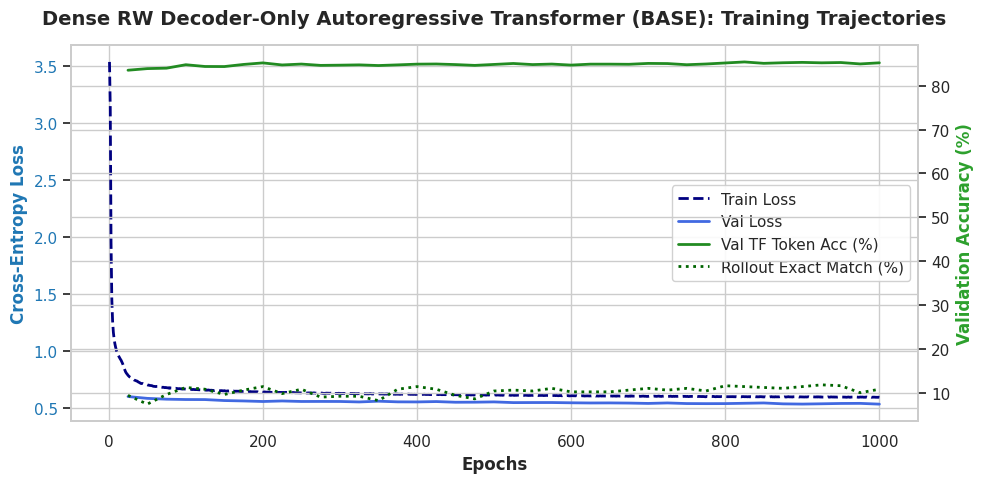

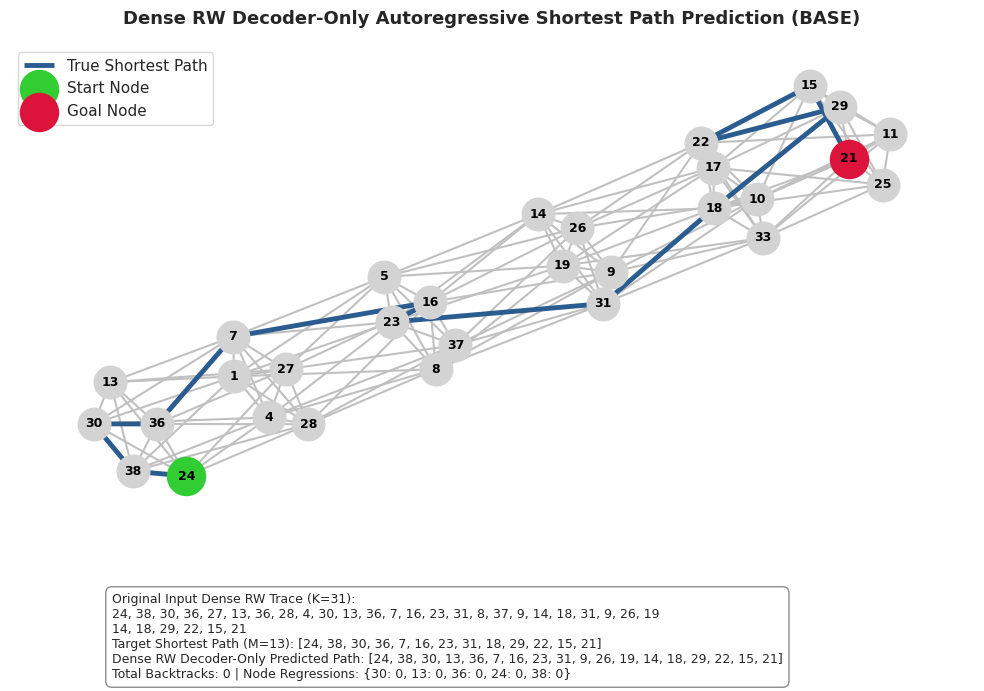

Dense RW Decoder-Only figures generated and saved.


In [7]:
# Cell 7: Generate Analytical Figures and Visual Layouts

sns.set_theme(style="whitegrid", palette="mako")

# Chart 1: Training Trajectories
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cross-Entropy Loss', color=color, fontsize=12, fontweight='bold')
epochs_range = range(1, len(history['train_loss']) + 1)
l1 = ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='navy', linewidth=2, linestyle='--')
if history['val_epochs']:
    l2 = ax1.plot(history['val_epochs'], history['val_loss'], label='Val Loss', color='royalblue', linewidth=2)
else:
    l2 = []
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Validation Accuracy (%)', color=color, fontsize=12, fontweight='bold')
if history['val_epochs']:
    l3 = ax2.plot(history['val_epochs'], history['val_tf_acc'], label='Val TF Token Acc (%)', color='forestgreen', linewidth=2)
    l4 = ax2.plot(history['val_epochs'], history['val_exact_match'], label='Rollout Exact Match (%)', color='darkgreen', linewidth=2, linestyle=':')
    lines = l1 + l2 + l3 + l4
else:
    lines = l1
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True, facecolor='white', framealpha=0.9)

plt.title(f'Dense RW Decoder-Only Autoregressive Transformer ({config["model_size"].upper()}): Training Trajectories', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
if os.path.basename(os.getcwd()) == "graphs":
    plt.savefig("../charts/decoder_only_ar_graph_rw_dense_training_curves.png", dpi=300, bbox_inches='tight')
    plt.savefig("charts/decoder_only_ar_graph_rw_dense_training_curves.png", dpi=300, bbox_inches='tight')
else:
    plt.savefig("charts/decoder_only_ar_graph_rw_dense_training_curves.png", dpi=300, bbox_inches='tight')
    plt.savefig("graphs/charts/decoder_only_ar_graph_rw_dense_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()

# Chart 2: Dense Graph Rollout Visualization
sample_inp, sample_lbl, sample_mask, sample_trace, sample_sp, G_sample, backtracks_sample, node_backtraces_sample = test_dataset[0]

model.eval()
with torch.no_grad():
    pred_rollout = model.solve_graph_autoregressive([sample_trace], device=device)[0]

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_sample, seed=42)

# Draw base graph
nx.draw_networkx_nodes(G_sample, pos, node_color='lightgray', node_size=550)
nx.draw_networkx_edges(G_sample, pos, edge_color='silver', width=1.5)

# Highlight Shortest Path Edges
sp_edges = [(sample_sp[i], sample_sp[i+1]) for i in range(len(sample_sp)-1)]
nx.draw_networkx_edges(G_sample, pos, edgelist=sp_edges, edge_color='#2b5c8f', width=3.5, label='True Shortest Path')

# Highlight Start and Destination Nodes
nx.draw_networkx_nodes(G_sample, pos, nodelist=[sample_sp[0]], node_color='limegreen', node_size=750, label='Start Node')
nx.draw_networkx_nodes(G_sample, pos, nodelist=[sample_sp[-1]], node_color='crimson', node_size=750, label='Goal Node')

labels = {node: str(node) for node in G_sample.nodes()}
nx.draw_networkx_labels(G_sample, pos, labels=labels, font_size=9, font_weight='bold')

# Formatted text block overlay
trace_str = f"Original Input Dense RW Trace (K={len(sample_trace)}):\n" + ", ".join(map(str, sample_trace[:25])) + "\n" + ", ".join(map(str, sample_trace[25:]))
sp_str = f"Target Shortest Path (M={len(sample_sp)}): {sample_sp}"
pred_str = f"Dense RW Decoder-Only Predicted Path: {pred_rollout}"
backtrack_str = f"Total Backtracks: {backtracks_sample} | Node Regressions: {dict(list(node_backtraces_sample.items())[:5])}"

plt.gcf().text(0.12, 0.02, f"{trace_str}\n{sp_str}\n{pred_str}\n{backtrack_str}",
               fontsize=9, bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.title(f"Dense RW Decoder-Only Autoregressive Shortest Path Prediction ({config['model_size'].upper()})", fontsize=13, fontweight='bold', pad=15)
plt.legend(scatterpoints=1, loc='upper left', frameon=True, facecolor='white')
plt.axis('off')
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

if os.path.basename(os.getcwd()) == "graphs":
    plt.savefig("../charts/decoder_only_ar_graph_rw_dense_sample_visualization.png", dpi=300, bbox_inches='tight')
    plt.savefig("charts/decoder_only_ar_graph_rw_dense_sample_visualization.png", dpi=300, bbox_inches='tight')
else:
    plt.savefig("charts/decoder_only_ar_graph_rw_dense_sample_visualization.png", dpi=300, bbox_inches='tight')
    plt.savefig("graphs/charts/decoder_only_ar_graph_rw_dense_sample_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

print("Dense RW Decoder-Only figures generated and saved.")


### Educational Self-Reflection & Dense Topology Mechanics

1. **Dense Topology Bifurcation Dynamics ($k \ge 4$)**:
   In dense multi-dimensional mesh topologies, every node presents at least 4-way bifurcations ($d_{\text{avg}} \ge 5.0$). Decoder-Only causal self-attention must attend across the concatenated prompt sequence to isolate valid forward step transitions among high decoy edge clutter ($> 60\%$ decoy ratio).
2. **Target Path Loss Masking & Optimization Efficiency**:
   By applying selective loss masking (`ignore_index = PAD_TOKEN`) over prompt positions ($0 \dots K-2$), 100% of gradient updates are concentrated on predicting path target tokens $p_1 \dots p_M$. This prevents capacity dilution on prompt trace modeling.
3. **Capacity Scaling Across Model Sizes (`small`, `base`, `large`)**:
   The notebook's dynamic sizing configuration enables systematic investigation of how model parameters (from ~25k in `small` to ~850k in `large`) affect causal prompt attention sharpening and rollout exact match accuracy under dense graph clutter.
